<a href="https://colab.research.google.com/github/strzelnat/machine_learning_basics/blob/main/basics/lasy_losowe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(font_scale = 1.5)
np.random.seed(42)

In [9]:
from sklearn.datasets import load_iris

raw_data = load_iris()
all_data = raw_data.copy()

data = all_data['data']
target = all_data['target']
feature_names = all_data['feature_names']
target_names = all_data['target_names']

In [13]:
#df = pd.DataFrame(data = np.c_[data, target], columns = feature_names + ['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [11]:
data = data[:,[0,1]]
target = df['target'].apply(int).values

print(f'{data[:5]}\n')
print(f'{target[:5]}\n')

[[5.1 3.5]
 [4.9 3. ]
 [4.7 3.2]
 [4.6 3.1]
 [5.  3.6]]

[0 0 0 0 0]



In [14]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators = 100, random_state = 42)

classifier.fit(data, target)

RandomForestClassifier(random_state=42)

In [15]:
classifier.score(data, target)

0.9266666666666666

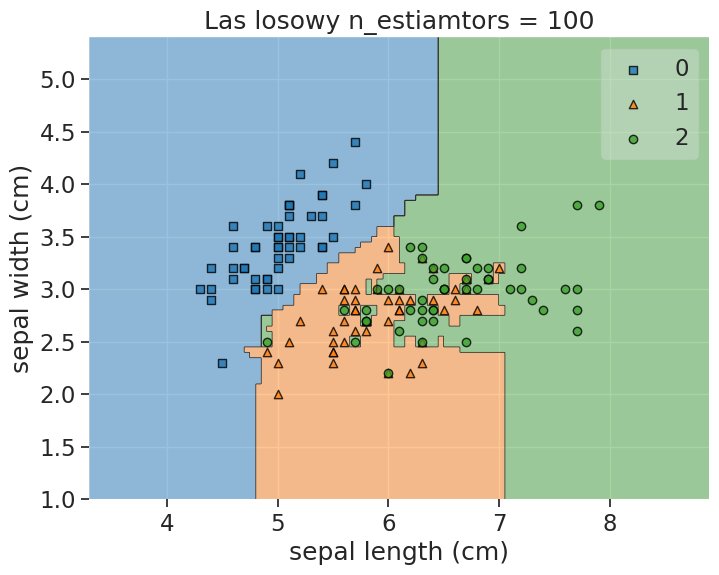

In [17]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(8,6))
plot_decision_regions(data, target, classifier)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Las losowy n_estiamtors = 100')
plt.show()

In [18]:
data = all_data['data']
targets = all_data['target']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(data, target)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', Y_train.shape)
print('y_test shape:', Y_test.shape)

X_train shape: (112, 4)
X_test shape: (38, 4)
y_train shape: (112,)
y_test shape: (38,)


In [23]:
classifier = RandomForestClassifier(n_estimators=100, random_state = 42)
classifier.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [24]:
from sklearn.metrics import accuracy_score

Y_pred = classifier.predict(X_test)
accuracy_score(Y_test, Y_pred)

1.0

In [25]:
classifier.feature_importances_

array([0.10968334, 0.02954459, 0.43763486, 0.42313721])

In [26]:
feauters_imp = pd.DataFrame(data = {'feauture': feature_names, 'importance': classifier.feature_importances_})

In [27]:
feauters_imp

,feauture,importance
0,sepal length (cm),0.109683
1,sepal width (cm),0.029545
2,petal length (cm),0.437635
3,petal width (cm),0.423137


In [29]:
px.bar(feauters_imp, x = 'feauture', y = 'importance', title = 'Importance of each characteristic')